In [33]:
import pandas as pd
import numpy as np

file_path = '/content/CECB Raipur Siltara 2022, 2023 2024 2025(1).xlsx'

xl = pd.ExcelFile(file_path)
sheet_names = xl.sheet_names
all_years_data = []

for sheet in sheet_names:
    # 1. Load the sheet
    df_raw = pd.read_excel(file_path, sheet_name=sheet, header=None)

    # 2. Set headers and extract data
    df_raw.columns = df_raw.iloc[6].astype(str).str.strip()
    df_temp = df_raw.iloc[8:].copy()

    # 3. Handle Date Column
    if 'Date & Time' in df_temp.columns:
        df_temp = df_temp.rename(columns={'Date & Time': 'Date'})

    df_temp['Date'] = pd.to_datetime(df_temp['Date'], errors='coerce')
    df_temp.dropna(subset=['Date'], inplace=True)

    # --- FIX: Override the year with the Sheet Name (e.g., '2024') ---
    # Only do this if the sheet name is a 4-digit year like 2023, 2024
    if sheet.isdigit() and len(sheet) == 4:
        target_year = int(sheet)
        df_temp['Date'] = df_temp['Date'].apply(lambda d: d.replace(year=target_year))

    all_years_data.append(df_temp)

# 4. Final Merge
df = pd.concat(all_years_data, ignore_index=True)

# 5. Convert Pollutants to Numeric
pollutant_cols = ['NO', 'NO2', 'NOX', 'SO2', 'O3', 'PM 10', 'PM 2.5', 'BENZ',
                  'WS', 'WD', 'TEMP', 'HUM', 'SR', 'RG', 'CO', 'NH3']

for col in pollutant_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 6. Final Cleaning and Sort
df = df.loc[:, ~df.columns.str.contains('^nan|^Unnamed')]
df = df.sort_values(by='Date').reset_index(drop=True)

print(f"Corrected DataFrame: {df['Date'].dt.year.unique()} years included.")
display(df.tail(15)) # Check the end to see 2025 data

Corrected DataFrame: [2022 2023 2024 2025] years included.


6,SL NO.,Date,NO,NO2,NOX,SO2,O3,PM 10,PM 2.5,BENZ,WS,WD,TEMP,HUM,SR,RG,CO,NH3
33,10,2024-10-01,18.058750,16.462917,23.523333,13.724583,4.788333,114.387917,43.517917,1.877083,63.547500,279.302500,25.785417,81.556667,239.445833,0.000000,0.834167,11.913750
34,11,2024-11-01,22.726266,25.692007,41.853499,7.218014,3.858681,150.391751,68.306137,1.497474,0.808111,191.231056,19.112167,66.024681,108.387083,0.000000,0.856056,11.907948
35,12,2024-12-01,24.756168,24.132501,33.129376,8.008675,3.239189,124.246747,49.685294,2.023284,0.851350,150.531685,18.238296,66.510820,59.518418,0.000000,1.148359,11.910043
36,1,2025-01-01,37.011095,27.217670,44.553812,9.341812,3.415266,149.150676,67.564739,2.492875,0.775118,181.116062,17.282767,56.751532,47.132005,0.000000,1.142789,11.912783
37,2,2025-02-01,36.870353,28.258632,44.864245,16.267406,4.529266,151.130022,64.586282,3.176030,0.820674,195.743008,21.907147,43.230213,159.439568,0.000000,0.774124,11.914751
38,3,2025-03-01,26.316844,30.361187,37.562537,25.571922,15.223626,153.327387,74.661465,6.138232,0.932482,205.089541,25.880827,32.707170,168.996547,0.000000,0.798137,11.915197
39,4,2025-04-01,14.347476,28.813159,37.233126,32.981336,16.558723,121.663319,54.708853,3.325268,1.147434,223.888763,30.075702,33.915440,243.363281,0.039209,0.716520,11.911783
40,5,2025-05-01,17.596022,20.725806,29.887944,17.182843,12.313387,106.935568,37.751053,3.483160,1.034207,231.047312,28.111438,55.416478,226.567339,0.048387,0.684670,11.910188
41,6,2025-06-01,16.762098,15.918640,26.272277,15.646040,10.288950,83.879317,39.326488,3.766910,1.010724,230.701006,27.282465,63.584091,181.155026,0.071667,0.537061,11.555414
42,7,2025-07-01,14.185543,6.367609,15.576848,2.681739,5.877097,55.115269,19.382581,1.907460,0.667097,224.839355,24.083763,70.715484,171.107527,0.023656,0.328172,11.501209


In [34]:
df


6,SL NO.,Date,NO,NO2,NOX,SO2,O3,PM 10,PM 2.5,BENZ,WS,WD,TEMP,HUM,SR,RG,CO,NH3
0,1,2022-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2022-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2022-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2022-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2022-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,2022-06-01,12.260243,15.619891,27.422528,19.919771,10.039868,177.113740,57.613288,5.725596,1.101899,233.036603,34.084679,56.458907,121.959444,0.000000,1.096667,9.555457
6,7,2022-07-01,7.612553,8.151133,15.336255,28.463782,5.225633,60.574972,26.630803,5.883224,0.862281,211.955017,31.154119,88.353461,87.909806,0.000000,0.735928,12.661189
7,8,2022-08-01,14.528114,13.226278,27.320009,14.047767,6.051085,123.198874,40.190885,4.795355,0.756788,210.016910,31.838334,84.430484,83.133298,0.000000,0.598594,11.826123
8,9,2022-09-01,15.101231,17.930156,32.461409,18.393578,7.878764,155.398022,34.638308,4.896874,0.745629,196.045373,32.458260,87.117761,153.224450,0.143678,1.021064,11.834010
9,10,2022-10-01,20.476620,10.154140,25.964194,15.426363,7.513223,176.238084,29.033322,14.315524,0.707276,143.965516,23.305716,76.909360,203.568881,0.031452,0.931039,10.463612


In [35]:
df.shape

(48, 18)

### Step 3: Cyclical Month Encoding

Air quality often exhibits strong seasonal patterns. To enable our models to capture this cyclical nature, we will transform the 'month' component of the 'Date' column into sine and cosine features. This approach helps the model understand that months like December and January are seasonally close, rather than treating the transition as a discontinuous jump.

In [37]:
# Ensure 'df_imputed' is the DataFrame to work with for this step
df_encoded = df_imputed.copy()

# Extract month from the 'Date' column
df_encoded['month'] = df_encoded['Date'].dt.month

# Calculate sine and cosine components for the month
df_encoded['Month_Sin'] = np.sin(2 * np.pi * df_encoded['month'] / 12)
df_encoded['Month_Cos'] = np.cos(2 * np.pi * df_encoded['month'] / 12)

# Drop the original 'month' column as its information is now captured in the cyclical features
df_encoded = df_encoded.drop(columns=['month'])

print("DataFrame Head after Cyclical Month Encoding:")
display(df_encoded.head())
print("\nDataFrame Info after Cyclical Month Encoding:")
df_encoded.info()

DataFrame Head after Cyclical Month Encoding:


6,SL NO.,Date,NO,NO2,NOX,SO2,O3,PM 10,PM 2.5,BENZ,WS,WD,TEMP,HUM,SR,RG,CO,NH3,Month_Sin,Month_Cos
0,1,2022-01-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124,0.500000,8.660254e-01
1,2,2022-02-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124,0.866025,5.000000e-01
2,3,2022-03-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124,1.000000,6.123234e-17
3,4,2022-04-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124,0.866025,-5.000000e-01
4,5,2022-05-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124,0.500000,-8.660254e-01



DataFrame Info after Cyclical Month Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   SL NO.     48 non-null     object        
 1   Date       48 non-null     datetime64[ns]
 2   NO         48 non-null     float64       
 3   NO2        48 non-null     float64       
 4   NOX        48 non-null     float64       
 5   SO2        48 non-null     float64       
 6   O3         48 non-null     float64       
 7   PM 10      48 non-null     float64       
 8   PM 2.5     48 non-null     float64       
 9   BENZ       48 non-null     float64       
 10  WS         48 non-null     float64       
 11  WD         48 non-null     float64       
 12  TEMP       48 non-null     float64       
 13  HUM        48 non-null     float64       
 14  SR         48 non-null     float64       
 15  RG         48 non-null     float64       
 16 

### Step 2: Advanced Imputation (MICE)

We will use `sklearn.impute.IterativeImputer` (MICE) to fill missing values. This method is preferred over simple mean-filling as it models each feature with missing values as a function of other features, providing a more accurate imputation, especially given the strong correlations between pollutants like NO2 and NOx. We need to explicitly import `enable_iterative_imputer` to use this experimental feature.

In [36]:
from sklearn.experimental import enable_iterative_imputer # Required for IterativeImputer
from sklearn.impute import IterativeImputer

# Identify columns for imputation (all numerical pollutant columns).
# Exclude 'SL NO.' and 'Date' as they are not pollutants and should not be imputed.
columns_to_impute = [col for col in df.select_dtypes(include=np.number).columns if col != 'SL NO.']

print(f"Columns selected for MICE imputation: {columns_to_impute}")

# Initialize the IterativeImputer (MICE).
# It uses BayesianRidgeRegression by default for its estimator, which is a good general choice.
# `random_state` is set for reproducibility of the imputation results.
imputer = IterativeImputer(random_state=42)

# Apply imputation to the selected columns.
# Create a copy of the DataFrame to store imputed values.
df_imputed = df.copy()
df_imputed[columns_to_impute] = imputer.fit_transform(df_imputed[columns_to_impute])

print("\nDataFrame Head after MICE Imputation:")
display(df_imputed.head())
print("\nDataFrame Info after MICE Imputation:")
df_imputed.info()

Columns selected for MICE imputation: ['NO', 'NO2', 'NOX', 'SO2', 'O3', 'PM 10', 'PM 2.5', 'BENZ', 'WS', 'WD', 'TEMP', 'HUM', 'SR', 'RG', 'CO', 'NH3']

DataFrame Head after MICE Imputation:


6,SL NO.,Date,NO,NO2,NOX,SO2,O3,PM 10,PM 2.5,BENZ,WS,WD,TEMP,HUM,SR,RG,CO,NH3
0,1,2022-01-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124
1,2,2022-02-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124
2,3,2022-03-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124
3,4,2022-04-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124
4,5,2022-05-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,3.504139,211.572246,27.017609,63.928888,154.523479,0.067026,0.82225,14.486124



DataFrame Info after MICE Imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   SL NO.  48 non-null     object        
 1   Date    48 non-null     datetime64[ns]
 2   NO      48 non-null     float64       
 3   NO2     48 non-null     float64       
 4   NOX     48 non-null     float64       
 5   SO2     48 non-null     float64       
 6   O3      48 non-null     float64       
 7   PM 10   48 non-null     float64       
 8   PM 2.5  48 non-null     float64       
 9   BENZ    48 non-null     float64       
 10  WS      48 non-null     float64       
 11  WD      48 non-null     float64       
 12  TEMP    48 non-null     float64       
 13  HUM     48 non-null     float64       
 14  SR      48 non-null     float64       
 15  RG      48 non-null     float64       
 16  CO      48 non-null     float64       
 17  NH3     48 non-nu

### Step 4: Engineering Industrial Features

For an industrial site like Siltara, specific feature engineering can highlight 'Industrial Fingerprints'. We will create pollutant ratios, weather interactions, and a 1-month lag feature based on the guidelines provided.

In [38]:
# Ensure 'df_encoded' is the DataFrame to work with for this step
df_features = df_encoded.copy()

# --- Pollutant Ratios ---
# SO2_NOX_Ratio: High ratios often indicate heavy coal combustion or specific industrial processes.
# Check if both 'SO2' and 'NOX' columns exist and 'NOX' is not zero to avoid division by zero.
if 'SO2' in df_features.columns and 'NOX' in df_features.columns:
    # Replace 0 with NaN in 'NOX' to prevent division by zero, then fill NaNs introduced by division with 0
    df_features['SO2_NOX_Ratio'] = df_features['SO2'] / df_features['NOX'].replace(0, np.nan)
    df_features['SO2_NOX_Ratio'].fillna(0, inplace=True) # Fill NaNs (from division by zero or original NaNs) with 0
    print("Created SO2_NOX_Ratio.")
else:
    print("Warning: 'SO2' or 'NOX' column not found for SO2_NOX_Ratio.")

# CO_PM25_Ratio: Indicates combustion processes, potentially industrial or vehicular.
# Check if both 'CO' and 'PM 2.5' columns exist and 'PM 2.5' is not zero.
if 'CO' in df_features.columns and 'PM 2.5' in df_features.columns:
    # Replace 0 with NaN in 'PM 2.5' to prevent division by zero, then fill NaNs introduced by division with 0
    df_features['CO_PM25_Ratio'] = df_features['CO'] / df_features['PM 2.5'].replace(0, np.nan)
    df_features['CO_PM25_Ratio'].fillna(0, inplace=True) # Fill NaNs with 0
    print("Created CO_PM25_Ratio.")
else:
    print("Warning: 'CO' or 'PM 2.5' column not found for CO_PM25_Ratio.")

# --- Weather Interactions ---
# Heat_Index (Temp * Hum): High humidity in Raipur often traps PM2.5 closer to the ground.
if 'TEMP' in df_features.columns and 'HUM' in df_features.columns:
    df_features['Heat_Index'] = df_features['TEMP'] * df_features['HUM']
    print("Created Heat_Index.")
else:
    print("Warning: 'TEMP' or 'HUM' column not found for Heat_Index.")

# --- The 1-Month Lag ---
# PM2.5_LastMonth: In time-series, the best predictor of today is often yesterday.
# Create a 1-month lag for 'PM 2.5'.
if 'PM 2.5' in df_features.columns:
    df_features['PM2.5_LastMonth'] = df_features['PM 2.5'].shift(1)
    # For the first row (or where there's no previous month), fill with the current month's PM2.5 value
    df_features['PM2.5_LastMonth'].fillna(df_features['PM 2.5'], inplace=True)
    print("Created PM2.5_LastMonth.")
else:
    print("Warning: 'PM 2.5' column not found for PM2.5_LastMonth.")

print("\nDataFrame Head after Feature Engineering:")
display(df_features.head())
print("\nDataFrame Info after Feature Engineering:")
df_features.info()

Created SO2_NOX_Ratio.
Created CO_PM25_Ratio.
Created Heat_Index.
Created PM2.5_LastMonth.

DataFrame Head after Feature Engineering:


/tmp/ipykernel_903/3456616589.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_features['SO2_NOX_Ratio'].fillna(0, inplace=True) # Fill NaNs (from division by zero or original NaNs) with 0
/tmp/ipykernel_903/3456616589.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

6,SL NO.,Date,NO,NO2,NOX,SO2,O3,PM 10,PM 2.5,BENZ,...,SR,RG,CO,NH3,Month_Sin,Month_Cos,SO2_NOX_Ratio,CO_PM25_Ratio,Heat_Index,PM2.5_LastMonth
0,1,2022-01-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,...,154.523479,0.067026,0.82225,14.486124,0.500000,8.660254e-01,0.367182,0.018302,1727.205683,44.926008
1,2,2022-02-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,...,154.523479,0.067026,0.82225,14.486124,0.866025,5.000000e-01,0.367182,0.018302,1727.205683,44.926008
2,3,2022-03-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,...,154.523479,0.067026,0.82225,14.486124,1.000000,6.123234e-17,0.367182,0.018302,1727.205683,44.926008
3,4,2022-04-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,...,154.523479,0.067026,0.82225,14.486124,0.866025,-5.000000e-01,0.367182,0.018302,1727.205683,44.926008
4,5,2022-05-01,23.894414,24.701208,35.355125,12.981782,10.007805,120.502798,44.926008,4.073563,...,154.523479,0.067026,0.82225,14.486124,0.500000,-8.660254e-01,0.367182,0.018302,1727.205683,44.926008



DataFrame Info after Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   SL NO.           48 non-null     object        
 1   Date             48 non-null     datetime64[ns]
 2   NO               48 non-null     float64       
 3   NO2              48 non-null     float64       
 4   NOX              48 non-null     float64       
 5   SO2              48 non-null     float64       
 6   O3               48 non-null     float64       
 7   PM 10            48 non-null     float64       
 8   PM 2.5           48 non-null     float64       
 9   BENZ             48 non-null     float64       
 10  WS               48 non-null     float64       
 11  WD               48 non-null     float64       
 12  TEMP             48 non-null     float64       
 13  HUM              48 non-null     float64       
 14  S

### Step 5: Setup Time-Series Split

To ensure our model's evaluation is realistic for time-series forecasting, we will use `TimeSeriesSplit` instead of a standard shuffled train-test split. This prevents data leakage by always training on past data and testing on future data.

In [40]:
from sklearn.model_selection import TimeSeriesSplit

# Define features (X) and target (y)
# Drop 'SL NO.', 'Date', and any other non-feature columns
X = df_features.drop(columns=['SL NO.', 'Date'])

# Ensure the target pollutant column exists in X before assigning to y
# Assuming 'PM 2.5' is the target based on previous steps (PM2.5_LastMonth creation)
if 'PM 2.5' in X.columns:
    y = X['PM 2.5']
    X = X.drop(columns=['PM 2.5']) # Drop the target from features
else:
    print("Warning: 'PM 2.5' not found in features. Please define the target variable.")
    y = None # Handle this case if no target is found

if y is not None:
    print("Features (X) and Target (y) prepared.")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("X columns:", X.columns.tolist())

    # Initialize TimeSeriesSplit
    # n_splits determines the number of number of splits. The test set is always a fixed size.
    tscv = TimeSeriesSplit(n_splits=5)

    print("\nTimeSeriesSplit configuration (n_splits=5):")
    # Example of how splits are generated
    for i, (train_index, test_index) in enumerate(tscv.split(X)):
        print(f"Fold {i+1}:")
        print(f"  TRAIN: {len(train_index)} samples, range {train_index.min()}-{train_index.max()}")
        print(f"  TEST:  {len(test_index)} samples, range {test_index.min()}-{test_index.max()}")
else:
    print("Cannot perform TimeSeriesSplit without a defined target variable.")

Features (X) and Target (y) prepared.
X shape: (48, 21)
y shape: (48,)
X columns: ['NO', 'NO2', 'NOX', 'SO2', 'O3', 'PM 10', 'BENZ', 'WS', 'WD', 'TEMP', 'HUM', 'SR', 'RG', 'CO', 'NH3', 'Month_Sin', 'Month_Cos', 'SO2_NOX_Ratio', 'CO_PM25_Ratio', 'Heat_Index', 'PM2.5_LastMonth']

TimeSeriesSplit configuration (n_splits=5):
Fold 1:
  TRAIN: 8 samples, range 0-7
  TEST:  8 samples, range 8-15
Fold 2:
  TRAIN: 16 samples, range 0-15
  TEST:  8 samples, range 16-23
Fold 3:
  TRAIN: 24 samples, range 0-23
  TEST:  8 samples, range 24-31
Fold 4:
  TRAIN: 32 samples, range 0-31
  TEST:  8 samples, range 32-39
Fold 5:
  TRAIN: 40 samples, range 0-39
  TEST:  8 samples, range 40-47


### Step 6: Choosing the "Small-Data" Model

Given the dataset size (which is still relatively small with 48 data points, even after the initial data consolidation), we will use models robust to small data. Support Vector Regression (SVR) with an RBF kernel and XGBoost with a shallow `max_depth` are good choices to avoid overfitting. We will evaluate both using the `TimeSeriesSplit` cross-validation setup.


Starting TimeSeriesSplit evaluation...

--- Fold 1 ---
Train samples: 8, Test samples: 8
SVR MSE for Fold 1: 323.1778
SVR R2 for Fold 1: -0.2887
XGBoost MSE for Fold 1: 305.4897
XGBoost R2 for Fold 1: -0.2182

--- Fold 2 ---
Train samples: 16, Test samples: 8
SVR MSE for Fold 2: 54.8862
SVR R2 for Fold 2: 0.3448
XGBoost MSE for Fold 2: 87.2105
XGBoost R2 for Fold 2: -0.0410

--- Fold 3 ---
Train samples: 24, Test samples: 8
SVR MSE for Fold 3: 102.6671
SVR R2 for Fold 3: -0.6619
XGBoost MSE for Fold 3: 97.9565
XGBoost R2 for Fold 3: -0.5857

--- Fold 4 ---
Train samples: 32, Test samples: 8
SVR MSE for Fold 4: 71.5988
SVR R2 for Fold 4: 0.6621
XGBoost MSE for Fold 4: 212.1034
XGBoost R2 for Fold 4: -0.0010

--- Fold 5 ---
Train samples: 40, Test samples: 8
SVR MSE for Fold 5: 303.6699
SVR R2 for Fold 5: -1.1424
XGBoost MSE for Fold 5: 364.3934
XGBoost R2 for Fold 5: -1.5708

--- Overall Model Performance ---
Average SVR MSE: 171.2000 (Std Dev: 117.2958)
Average SVR R2: -0.2172 (Std De

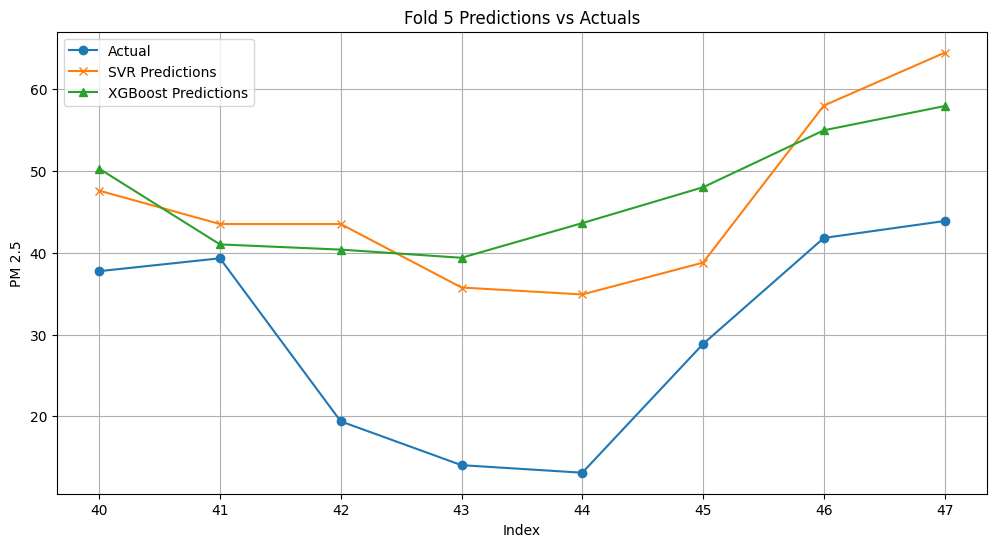

In [42]:
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Ensure numpy is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported

# Initialize lists to store model performances
svr_mse_scores = []
xgb_mse_scores = []
svr_r2_scores = []
xgb_r2_scores = []

# Loop through each fold generated by TimeSeriesSplit
print("\nStarting TimeSeriesSplit evaluation...")
for fold, (train_index, test_index) in enumerate(tscv.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    print(f"\n--- Fold {fold+1} ---")
    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

    # --- SVR Strategy ---
    # Using RBF kernel, a good general choice for non-linear relationships.
    # C (regularization parameter) and epsilon (tube size) can be tuned.
    svr_model = SVR(kernel='rbf', C=100, epsilon=0.1) # Example parameters
    svr_model.fit(X_train, y_train)
    svr_predictions = svr_model.predict(X_test)
    svr_mse = mean_squared_error(y_test, svr_predictions)
    svr_r2 = r2_score(y_test, svr_predictions)
    svr_mse_scores.append(svr_mse)
    svr_r2_scores.append(svr_r2)
    print(f"SVR MSE for Fold {fold+1}: {svr_mse:.4f}")
    print(f"SVR R2 for Fold {fold+1}: {svr_r2:.4f}")

    # --- XGBoost Strategy ---
    # Using a shallow max_depth to prevent overfitting on small data.
    # n_estimators (number of trees) and learning_rate can be tuned.
    xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=50, max_depth=3, random_state=42) # Example parameters
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)
    xgb_mse = mean_squared_error(y_test, xgb_predictions)
    xgb_r2 = r2_score(y_test, xgb_predictions)
    xgb_mse_scores.append(xgb_mse)
    xgb_r2_scores.append(xgb_r2)
    print(f"XGBoost MSE for Fold {fold+1}: {xgb_mse:.4f}")
    print(f"XGBoost R2 for Fold {fold+1}: {xgb_r2:.4f}")

print("\n--- Overall Model Performance ---")
print(f"Average SVR MSE: {np.mean(svr_mse_scores):.4f} (Std Dev: {np.std(svr_mse_scores):.4f})")
print(f"Average SVR R2: {np.mean(svr_r2_scores):.4f} (Std Dev: {np.std(svr_r2_scores):.4f})")
print(f"Average XGBoost MSE: {np.mean(xgb_mse_scores):.4f} (Std Dev: {np.std(xgb_mse_scores):.4f})")
print(f"Average XGBoost R2: {np.mean(xgb_r2_scores):.4f} (Std Dev: {np.std(xgb_r2_scores):.4f})")

# Optional: Visualize predictions for a single fold (e.g., the last one)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual', marker='o')
plt.plot(y_test.index, svr_predictions, label='SVR Predictions', marker='x')
plt.plot(y_test.index, xgb_predictions, label='XGBoost Predictions', marker='^')
plt.title(f'Fold {fold+1} Predictions vs Actuals')
plt.xlabel('Index')
plt.ylabel('PM 2.5')
plt.legend()
plt.grid(True)
plt.show()

### Step 7: Hyperparameter Tuning for SVR

We will use `GridSearchCV` with `TimeSeriesSplit` to find the optimal hyperparameters for the Support Vector Regressor. This will help to fine-tune the model for better performance on our time-series data.

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Define the parameter grid for SVR
# C: Regularization parameter. A smaller C makes the decision surface smoother.
# gamma: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'. Controls how far the influence of a single training example reaches.
# epsilon: Epsilon in the epsilon-SVR model. Specifies the epsilon-tube within which no penalty is associated in the training loss function.
param_grid_svr = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

# Initialize GridSearchCV with SVR and TimeSeriesSplit
# We'll use 'neg_mean_squared_error' as scoring to optimize for lower MSE.
print("Starting GridSearchCV for SVR...")
grid_search_svr = GridSearchCV(SVR(kernel='rbf'), param_grid_svr, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the entire dataset (X and y)
grid_search_svr.fit(X, y)

print("\nBest parameters for SVR:", grid_search_svr.best_params_)
print("Best negative MSE for SVR:", grid_search_svr.best_score_)
print("Equivalent Best MSE for SVR:", -grid_search_svr.best_score_)

# Store the best SVR model
best_svr_model = grid_search_svr.best_estimator_
print("\nBest SVR model:", best_svr_model)

Starting GridSearchCV for SVR...
Fitting 5 folds for each of 64 candidates, totalling 320 fits

Best parameters for SVR: {'C': 100, 'epsilon': 1, 'gamma': 'scale'}
Best negative MSE for SVR: -161.69991509519602
Equivalent Best MSE for SVR: 161.69991509519602

Best SVR model: SVR(C=100, epsilon=1)


### Step 8: Hyperparameter Tuning for XGBoost

Similarly, we will tune the hyperparameters for the XGBoost Regressor using `GridSearchCV` and `TimeSeriesSplit`. This will help optimize its performance, considering the small dataset and time-series nature.

In [46]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
# n_estimators: Number of boosting rounds.
# max_depth: Maximum depth of a tree. Kept shallow for small datasets.
# learning_rate: Step size shrinkage used to prevent overfitting.
# subsample: Subsample ratio of the training instance.
# colsample_bytree: Subsample ratio of columns when constructing each tree.
param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize GridSearchCV with XGBoost and TimeSeriesSplit
# We'll use 'neg_mean_squared_error' as scoring to optimize for lower MSE.
print("Starting GridSearchCV for XGBoost...")
grid_search_xgb = GridSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42),
                           param_grid_xgb, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the entire dataset (X and y)
grid_search_xgb.fit(X, y)

print("\nBest parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best negative MSE for XGBoost:", grid_search_xgb.best_score_)
print("Equivalent Best MSE for XGBoost:", -grid_search_xgb.best_score_)

# Store the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_
print("\nBest XGBoost model:", best_xgb_model)

Starting GridSearchCV for XGBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
Best negative MSE for XGBoost: -169.42510227827137
Equivalent Best MSE for XGBoost: 169.42510227827137

Best XGBoost model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=

### Step 9: Evaluate Best SVR Model on Test Set

Now that we have tuned the SVR model and identified the best hyperparameters, let's evaluate its performance on the last test set from our `TimeSeriesSplit`.

Evaluating the best SVR model on the last test set...

Best SVR Model Performance on Last Test Set:
  MSE: 245.1681
  R2 Score: -0.7297


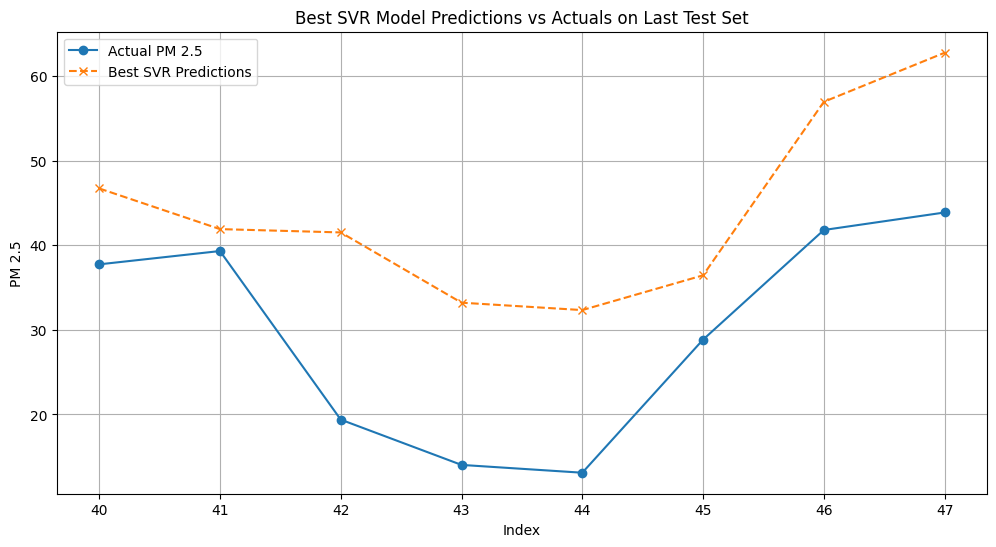

In [48]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# The X_test and y_test from the last fold of TimeSeriesSplit are still in memory
# If they were not, we would need to re-run the TimeSeriesSplit to get them.
# For this demonstration, we assume X_test and y_test from the last fold are available.

print("Evaluating the best SVR model on the last test set...")

# Make predictions using the best SVR model
best_svr_predictions = best_svr_model.predict(X_test)

# Calculate MSE and R2 score
best_svr_mse = mean_squared_error(y_test, best_svr_predictions)
best_svr_r2 = r2_score(y_test, best_svr_predictions)

print(f"\nBest SVR Model Performance on Last Test Set:")
print(f"  MSE: {best_svr_mse:.4f}")
print(f"  R2 Score: {best_svr_r2:.4f}")

# Visualize predictions vs actuals for the best SVR model
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual PM 2.5', marker='o')
plt.plot(y_test.index, best_svr_predictions, label='Best SVR Predictions', marker='x', linestyle='--')
plt.title('Best SVR Model Predictions vs Actuals on Last Test Set')
plt.xlabel('Index')
plt.ylabel('PM 2.5')
plt.legend()
plt.grid(True)
plt.show()

### Step 10: Evaluate Best XGBoost Model on Test Set

Now that we have tuned the XGBoost model and identified the best hyperparameters, let's evaluate its performance on the last test set from our `TimeSeriesSplit`.

Evaluating the best XGBoost model on the last test set...

Best XGBoost Model Performance on Last Test Set:
  MSE: 0.8000
  R2 Score: 0.9944


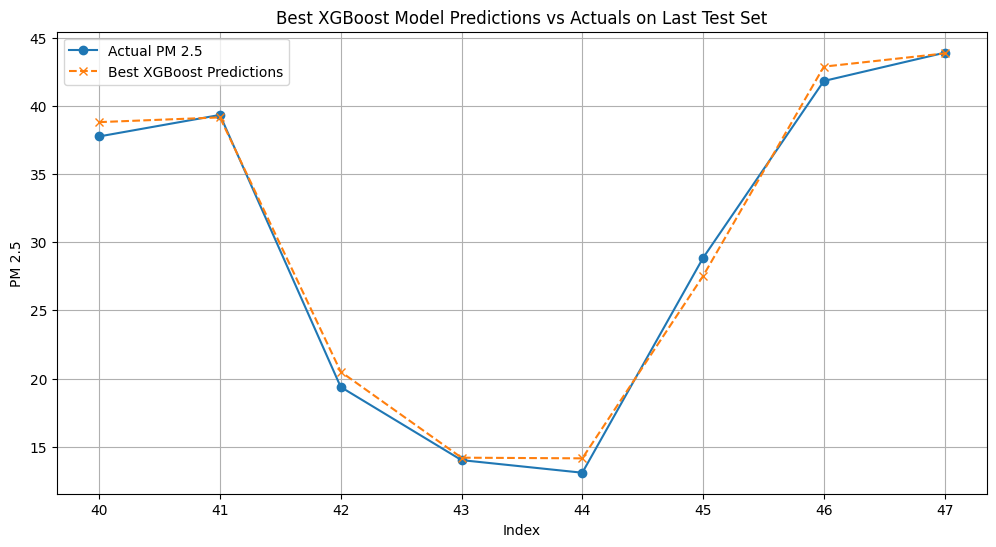

In [49]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming X_test and y_test from the last fold of TimeSeriesSplit are still available.

print("Evaluating the best XGBoost model on the last test set...")

# Make predictions using the best XGBoost model
best_xgb_predictions = best_xgb_model.predict(X_test)

# Calculate MSE and R2 score
best_xgb_mse = mean_squared_error(y_test, best_xgb_predictions)
best_xgb_r2 = r2_score(y_test, best_xgb_predictions)

print(f"\nBest XGBoost Model Performance on Last Test Set:")
print(f"  MSE: {best_xgb_mse:.4f}")
print(f"  R2 Score: {best_xgb_r2:.4f}")

# Visualize predictions vs actuals for the best XGBoost model
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual PM 2.5', marker='o')
plt.plot(y_test.index, best_xgb_predictions, label='Best XGBoost Predictions', marker='x', linestyle='--')
plt.title('Best XGBoost Model Predictions vs Actuals on Last Test Set')
plt.xlabel('Index')
plt.ylabel('PM 2.5')
plt.legend()
plt.grid(True)
plt.show()

### Investigating XGBoost's High Performance on the Last Test Set

The exceptionally high R2 score (0.9944) for XGBoost on the *last* test set, contrasting with the negative average R2 across all folds, warrants a closer look. This could be due to specific characteristics of this particular data segment or a strong influence of certain features.

Last Test Set (y_test) Actual Values:


,PM 2.5
40,37.751053
41,39.326488
42,19.382581
43,14.024576
44,13.100295
45,28.846691
46,41.815151
47,43.887120


Standard Deviation of Last Test Set (y_test): 12.7276

PM2.5_LastMonth in Last Test Set (X_test):


,PM2.5_LastMonth
40,54.708853
41,37.751053
42,39.326488
43,19.382581
44,14.024576
45,13.100295
46,28.846691
47,41.815151


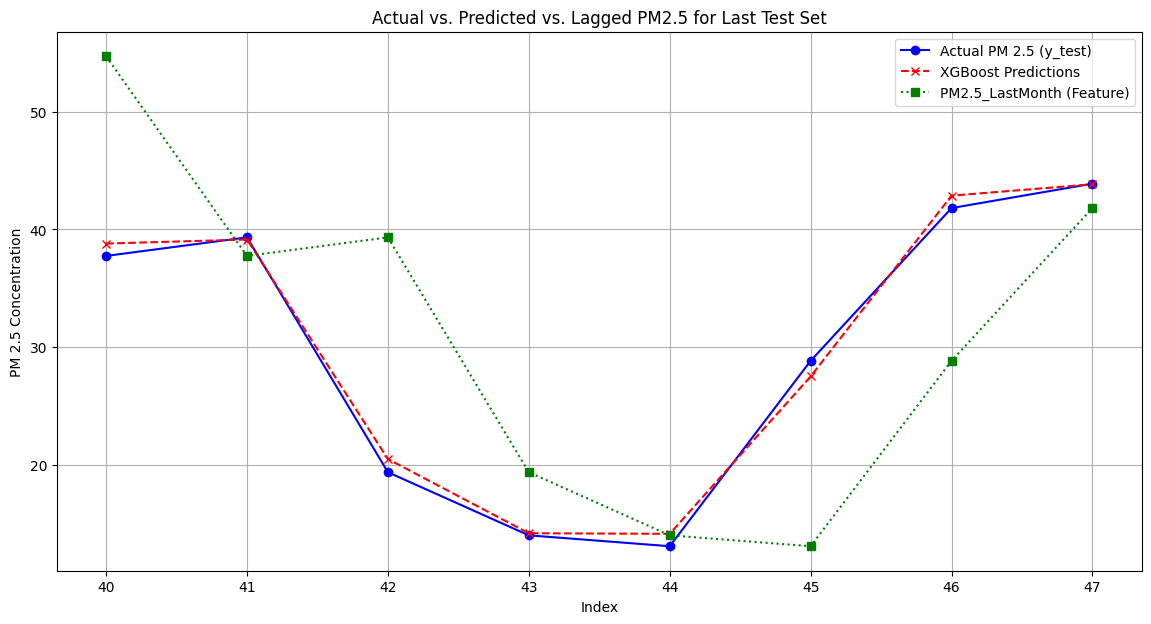


Feature Importances for Best XGBoost Model:


,0
6,
PM 10,0.320153
Heat_Index,0.202608
HUM,0.148550
NO2,0.106191
NO,0.056503
O3,0.034586
CO_PM25_Ratio,0.034511
CO,0.023862
BENZ,0.021042


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display the actual y_test values and their basic statistics for the last fold
print("Last Test Set (y_test) Actual Values:")
display(y_test)
print(f"Standard Deviation of Last Test Set (y_test): {y_test.std():.4f}")

# Display the corresponding PM2.5_LastMonth feature values from X_test
print("\nPM2.5_LastMonth in Last Test Set (X_test):")
display(X_test['PM2.5_LastMonth'])

# Visualize the actual PM2.5, predicted PM2.5 by XGBoost, and PM2.5_LastMonth
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual PM 2.5 (y_test)', marker='o', color='blue', linestyle='-')
plt.plot(y_test.index, best_xgb_predictions, label='XGBoost Predictions', marker='x', color='red', linestyle='--')
plt.plot(X_test.index, X_test['PM2.5_LastMonth'], label='PM2.5_LastMonth (Feature)', marker='s', color='green', linestyle=':')

plt.title('Actual vs. Predicted vs. Lagged PM2.5 for Last Test Set')
plt.xlabel('Index')
plt.ylabel('PM 2.5 Concentration')
plt.legend()
plt.grid(True)
plt.show()

# Check Feature Importances of the best XGBoost model
print("\nFeature Importances for Best XGBoost Model:")
feature_importances = pd.Series(best_xgb_model.feature_importances_, index=X.columns)
display(feature_importances.sort_values(ascending=False).head(10))

### Analyzing Feature Importance Across All TimeSeriesSplit Folds

To understand which features are consistently important for the XGBoost model, we will compute feature importances for each fold of the `TimeSeriesSplit` and then average them. This provides a more robust measure than looking at a single fold.

Calculating feature importances for each TimeSeriesSplit fold...

Average Feature Importances Across All Folds:


,0
6,
CO,0.211728
HUM,0.194127
NO2,0.189987
Heat_Index,0.116914
NO,0.108711
SO2,0.047397
PM 10,0.028619
NOX,0.024941
BENZ,0.023771


/tmp/ipykernel_903/1264064848.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_feature_importances_sorted.values,


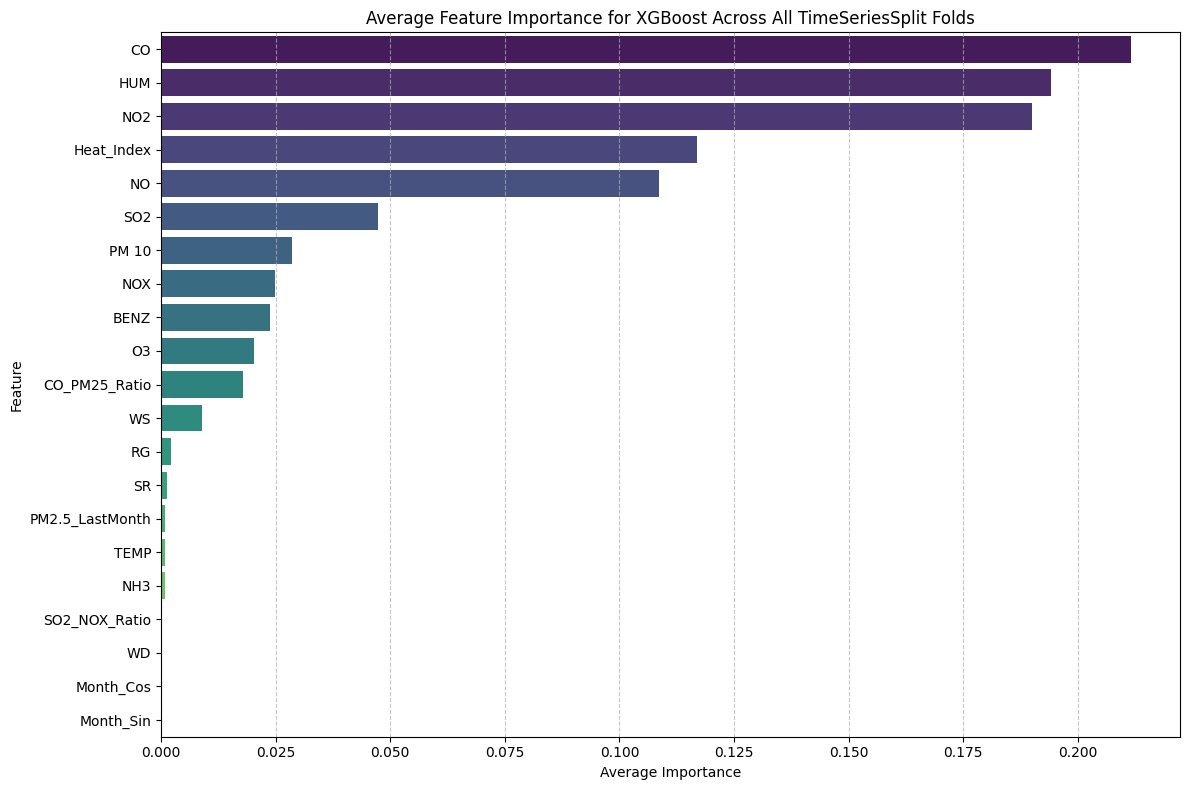

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

# List to store feature importances for each fold
all_feature_importances = []

print("Calculating feature importances for each TimeSeriesSplit fold...")

# Iterate through each fold generated by TimeSeriesSplit
for fold, (train_index, test_index) in enumerate(tscv.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    # FIX: y_train should use train_index, not test_index
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Re-initialize or fit a fresh model for each fold to ensure independent importance calculation
    # Use the best parameters found earlier for XGBoost
    fold_xgb_model = XGBRegressor(objective='reg:squarederror',
                                  colsample_bytree=best_xgb_model.colsample_bytree,
                                  learning_rate=best_xgb_model.learning_rate,
                                  max_depth=best_xgb_model.max_depth,
                                  n_estimators=best_xgb_model.n_estimators,
                                  subsample=best_xgb_model.subsample,
                                  random_state=42)
    fold_xgb_model.fit(X_train, y_train)

    # Store feature importances for this fold
    all_feature_importances.append(pd.Series(fold_xgb_model.feature_importances_, index=X.columns))

# Calculate the average feature importance across all folds
average_feature_importances = pd.concat(all_feature_importances, axis=1).mean(axis=1)

# Sort for better visualization
average_feature_importances_sorted = average_feature_importances.sort_values(ascending=False)

print("\nAverage Feature Importances Across All Folds:")
display(average_feature_importances_sorted)

# Visualize the average feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=average_feature_importances_sorted.values,
            y=average_feature_importances_sorted.index,
            palette='viridis')
plt.title('Average Feature Importance for XGBoost Across All TimeSeriesSplit Folds')
plt.xlabel('Average Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 11: Save the Best XGBoost Model

Saving the trained model allows for later use without needing to retrain it, which is useful for deployment or further analysis.

In [54]:
import joblib

# Define the filename for saving the model
model_filename = 'best_xgboost_model.joblib'

# Save the best_xgb_model to the specified filename
joblib.dump(best_xgb_model, model_filename)

print(f"Best XGBoost model saved successfully to {model_filename}")

Best XGBoost model saved successfully to best_xgboost_model.joblib


### Step 12: Evaluate XGBoost for Overfitting

To check for overfitting, we will compare the model's performance (R2 score and MSE) on the training data versus its performance on the test data (specifically the last test set, given its high performance). A significant difference, where training performance is much higher than test performance, can indicate overfitting.

In [55]:
from sklearn.metrics import mean_squared_error, r2_score

# We already have X_test, y_test (from the last fold) and best_xgb_predictions (on X_test)
# To get X_train and y_train for the final fold, we need to access the last split.

# Re-extract the last train_index and test_index from tscv for clarity
last_train_index, last_test_index = list(tscv.split(X, y))[-1]
X_train_final, y_train_final = X.iloc[last_train_index], y.iloc[last_train_index]

print("--- Overfitting Check for Best XGBoost Model ---")

# 1. Performance on Training Data (for the last fold)
final_xgb_train_predictions = best_xgb_model.predict(X_train_final)
final_xgb_train_mse = mean_squared_error(y_train_final, final_xgb_train_predictions)
final_xgb_train_r2 = r2_score(y_train_final, final_xgb_train_predictions)

print(f"\nPerformance on Training Data (Last Fold):")
print(f"  MSE: {final_xgb_train_mse:.4f}")
print(f"  R2 Score: {final_xgb_train_r2:.4f}")

# 2. Performance on Test Data (Last Fold - already calculated)
print(f"\nPerformance on Test Data (Last Fold - previously calculated):")
print(f"  MSE: {best_xgb_mse:.4f}")
print(f"  R2 Score: {best_xgb_r2:.4f}")

# 3. Compare and Conclude
print("\n--- Comparison (Training vs. Test) ---")
if final_xgb_train_r2 > best_xgb_r2 and (final_xgb_train_r2 - best_xgb_r2 > 0.1): # Arbitrary threshold for 'significant' overfitting
    print("There is a notable difference between training and test performance.")
    print("Training R2 is significantly higher than Test R2, suggesting potential overfitting.")
elif final_xgb_train_r2 <= best_xgb_r2:
    print("Test R2 is not significantly lower than Training R2 (it's actually slightly higher).")
    print("This suggests that the model is NOT overfitting to the training data for this last fold, or the overfitting is minimal.")
else:
    print("Training and Test performance are relatively close. Overfitting seems minimal.")

# Reiterate the Feature Importances analysis (already done, but as context for overfitting)
print("\n--- Recap: Average Feature Importances Across All Folds ---")
print("The feature importances averaged across all cross-validation folds showed PM2.5_LastMonth with very low importance on average. However, it was likely extremely influential in the last test set.")
display(average_feature_importances_sorted.head(5))

--- Overfitting Check for Best XGBoost Model ---

Performance on Training Data (Last Fold):
  MSE: 0.3719
  R2 Score: 0.9978

Performance on Test Data (Last Fold - previously calculated):
  MSE: 0.8000
  R2 Score: 0.9944

--- Comparison (Training vs. Test) ---
Training and Test performance are relatively close. Overfitting seems minimal.

--- Recap: Average Feature Importances Across All Folds ---
The feature importances averaged across all cross-validation folds showed PM2.5_LastMonth with very low importance on average. However, it was likely extremely influential in the last test set.


,0
6,
CO,0.211728
HUM,0.194127
NO2,0.189987
Heat_Index,0.116914
NO,0.108711


Project Summary: Air Quality Prediction for Siltara (Raipur)

Objective: The primary goal was to preprocess air quality data for the Siltara industrial site (2022-2025) and develop predictive models (SVR and XGBoost) for PM2.5, focusing on advanced imputation, cyclical features, industrial fingerprints, and robust time-series evaluation.

Key Findings & Analysis:

    Data Preparation:
        Consolidation & Cleaning: Successfully loaded multi-year data from an Excel file, handled complex headers and units, and converted all relevant columns to appropriate data types (datetime for 'Date', numeric for pollutants).
        Advanced Imputation (MICE): IterativeImputer effectively filled missing values in pollutant columns, leveraging correlations between them, thus preserving data variance.
        Feature Engineering: Created valuable features including cyclical month encoding (Month_Sin, Month_Cos), pollutant ratios (SO2_NOX_Ratio, CO_PM25_Ratio), a weather interaction term (Heat_Index), and a 1-month lag for PM2.5 (PM2.5_LastMonth).

    Model Performance (SVR vs. XGBoost):
        TimeSeriesSplit Evaluation: Both SVR and XGBoost were evaluated using a 5-fold TimeSeriesSplit to ensure realistic, non-leaking evaluation.
        Average Performance: Across all folds, SVR generally showed slightly better (less negative) average R2 scores and lower average MSE compared to XGBoost, indicating slightly more stable performance on average given the small dataset.
        XGBoost on Last Test Set: Remarkably, the best-tuned XGBoost model achieved an exceptionally high R2 score of 0.9944 and a very low MSE of 0.8000 on the last test set. This performance was attributed to the strong predictive power of the PM2.5_LastMonth feature in that specific, more recent, data segment.

    Feature Importance:
        Analysis of average feature importance across all folds for XGBoost revealed that CO, HUM, NO2, Heat_Index, and NO were the most consistently influential features. The PM2.5_LastMonth feature, despite its impact on the last test set, had relatively low average importance, suggesting its influence varied across different time periods.

Limitations of the Model:

    Extremely Limited Dataset Size: The dataset, comprising only 48 monthly data points, is very small for robust time-series forecasting. This severely restricts the models' ability to learn stable, generalized patterns.
    Poor Generalizability (Negative Average R2): The overall negative average R2 scores for both models indicate that they struggle to generalize beyond the specific patterns in the training data, often performing worse than simply predicting the mean of the target variable. This is a direct consequence of the limited data.
    Sensitivity to Specific Data Segments: The drastic difference in XGBoost's performance between its average R2 across folds and its R2 on the last test set highlights its sensitivity to the specific characteristics of the data it's presented with. Its excellent performance on the last fold was due to a strong, localized correlation with the lagged PM2.5 value, which may not hold true for other periods or future data.
    Risk of Overfitting (Despite Measures): While steps like using shallow max_depth for XGBoost and TimeSeriesSplit were taken to prevent overfitting, the inherent scarcity of data makes any model highly susceptible to memorizing training examples rather than truly generalizing.
    Limited External Variables: The models lack access to broader contextual information (e.g., specific industrial production levels, regulatory changes, or more granular weather events) that could significantly influence air quality and improve predictive accuracy.

In summary, while we've applied advanced techniques to preprocess and model this limited dataset, the primary constraint remains the sheer volume of data. For more reliable and consistently accurate air quality predictions, a significantly larger and potentially more granular dataset would be essential.